
# 고양이 수염 스티커 만들기


# 1.라이브러리 임포트 및 이미지 코드

In [1]:
import os
import cv2
import dlib
import matplotlib.pyplot as plt
import numpy as np

# 경로 설정
home_dir = os.getenv('HOME')
img_path = os.path.join(home_dir, 'work/camera_sticker/images/cho.png')
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/cat-whiskers.png')

# 이미지 로드 및 기본 변환
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# dlib 모델 로드
detector_hog = dlib.get_frontal_face_detector()
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
predictor = dlib.shape_predictor(model_path)

print("준비 완료! 다음 셀을 실행하세요.")

준비 완료! 다음 셀을 실행하세요.


# 2.코 끝 기준(33번) 점 표시 및 스티커 합성 코드

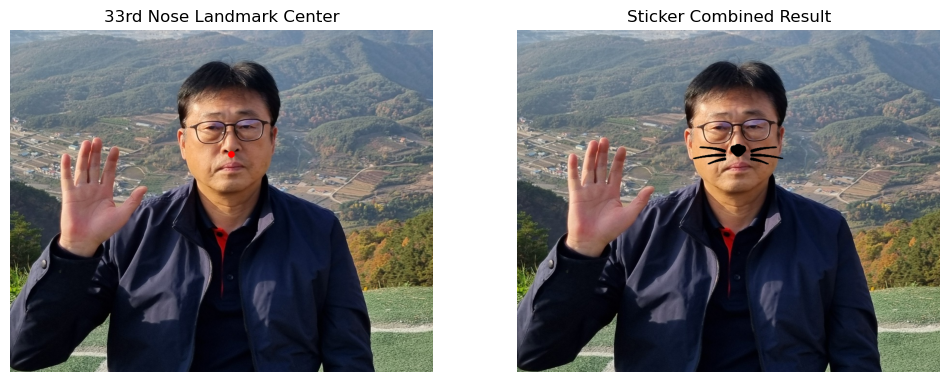

In [2]:
# 이미지 초기화
img_show = img_rgb.copy()
dlib_rects = detector_hog(img_rgb, 1)

if len(dlib_rects) > 0:
    dlib_rect = dlib_rects[0]
    points = predictor(img_rgb, dlib_rect)
    
    # 33번 코 끝 좌표 추출
    x_nose = points.part(33).x
    y_nose = points.part(33).y
    
    # [시각화] 예시 이미지처럼 원본 위에 코 끝 기준점(빨간 원) 표시
    img_with_center = img_rgb.copy()
    cv2.circle(img_with_center, (x_nose, y_nose), 7, (255, 0, 0), -1) 
    
    # 스티커 크기 및 시작 좌상단(x, y) 계산
    w_sticker = dlib_rect.width()
    h_sticker = dlib_rect.width()
    x = x_nose - w_sticker // 2
    y = y_nose - h_sticker // 2
    
    # 경계 처리
    if x < 0: x = 0
    if y < 0: y = 0
    
    # 스티커 로드 및 합성
    img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
    img_sticker = cv2.resize(img_sticker, (w_sticker, h_sticker))
    
    sticker_area = img_show[y:y+h_sticker, x:x+w_sticker]
    alpha_sticker = img_sticker[:, :, 3] / 255.0
    alpha_bg = 1.0 - alpha_sticker
    
    for c in range(3):
        sticker_area[:, :, c] = (alpha_sticker * img_sticker[:, :, c] + alpha_bg * sticker_area[:, :, c])
    img_show[y:y+h_sticker, x:x+w_sticker] = sticker_area

    # 결과 시각화
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_with_center)
    plt.title("33rd Nose Landmark Center")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_show)
    plt.title("Sticker Combined Result")
    plt.axis('off')
    plt.show()
else:
    print("얼굴을 검출하지 못했습니다.")

# 3. 얼굴 각도 변경 시뮬레이션 (이미지 회전)

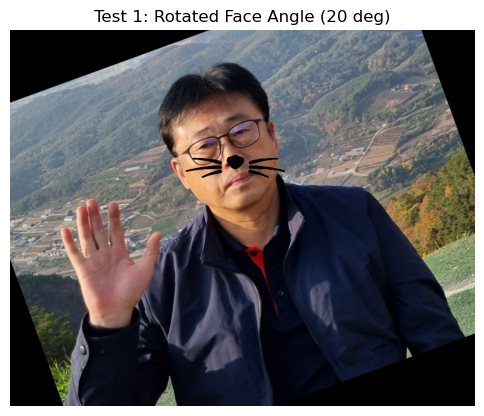

분석 결과: 얼굴이 회전해도 코 끝은 찾지만, 스티커가 수평으로 배치되어 얼굴 각도와 어긋납니다.


In [3]:
# 원본 이미지를 임의로 20도 회전시켜 '기울어진 얼굴' 생성
(h, w) = img_rgb.shape[:2]
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 20, 1.0) # 20도 회전
img_rotated = cv2.warpAffine(img_rgb, rotation_matrix, (w, h))

img_rotated_show = img_rotated.copy()
rects_rot = detector_hog(img_rotated, 1)

if len(rects_rot) > 0:
    points = predictor(img_rotated, rects_rot[0])
    x_nose = points.part(33).x
    y_nose = points.part(33).y
    
    w_sticker = rects_rot[0].width()
    h_sticker = rects_rot[0].width()
    x = x_nose - w_sticker // 2
    y = y_nose - h_sticker // 2
    
    img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
    img_sticker = cv2.resize(img_sticker, (w_sticker, h_sticker))
    
    # 경계 예외 처리 적용하여 슬라이싱 에러 방지
    y_start, y_end = max(0, y), min(h, y+h_sticker)
    x_start, x_end = max(0, x), min(w, x+w_sticker)
    
    sticker_area = img_rotated_show[y_start:y_end, x_start:x_end]
    # 회전 환경에 맞게 스티커 슬라이싱 크기 일치화
    img_sticker_sub = img_sticker[0:(y_end-y_start), 0:(x_end-x_start)]
    
    alpha_sticker = img_sticker_sub[:, :, 3] / 255.0
    alpha_bg = 1.0 - alpha_sticker
    
    for c in range(3):
        sticker_area[:, :, c] = (alpha_sticker * img_sticker_sub[:, :, c] + alpha_bg * sticker_area[:, :, c])
        
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rotated_show)
    plt.title("Test 1: Rotated Face Angle (20 deg)")
    plt.axis('off')
    plt.show()
    print("분석 결과: 얼굴이 회전해도 코 끝은 찾지만, 스티커가 수평으로 배치되어 얼굴 각도와 어긋납니다.")
else:
    print("분석 결과: 각도가 과도하게 기울어지면 HOG 디텍터가 얼굴을 감지하지 못합니다.")

# 4.이미지 밝기 변경 시뮬레이션

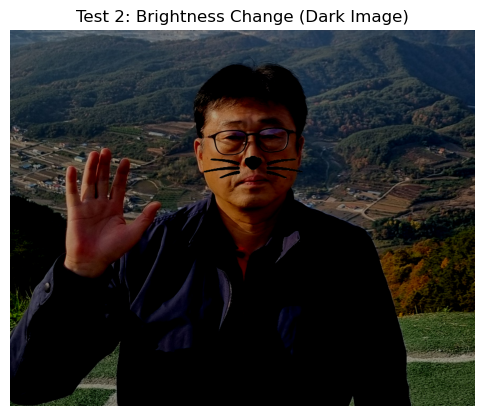

분석 결과: 명암 대비가 약해지면 이목구비 경계가 흐려져 랜드마크가 정밀하지 못하거나 실패할 확률이 높습니다.


In [4]:
# 이미지를 어둡게 변경 (픽셀 값 감소)
matrix = np.ones(img_rgb.shape, dtype="uint8") * 80
img_dark = cv2.subtract(img_rgb, matrix)

img_dark_show = img_dark.copy()
rects_dark = detector_hog(img_dark, 1)

if len(rects_dark) > 0:
    points = predictor(img_dark, rects_dark[0])
    x_nose = points.part(33).x
    y_nose = points.part(33).y
    
    w_sticker = rects_dark[0].width()
    h_sticker = rects_dark[0].width()
    x = x_nose - w_sticker // 2
    y = y_nose - h_sticker // 2
    
    img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
    img_sticker = cv2.resize(img_sticker, (w_sticker, h_sticker))
    
    sticker_area = img_dark_show[y:y+h_sticker, x:x+w_sticker]
    alpha_sticker = img_sticker[:, :, 3] / 255.0
    alpha_bg = 1.0 - alpha_sticker
    
    for c in range(3):
        sticker_area[:, :, c] = (alpha_sticker * img_sticker[:, :, c] + alpha_bg * sticker_area[:, :, c])
        
    plt.figure(figsize=(6, 6))
    plt.imshow(img_dark_show)
    plt.title("Test 2: Brightness Change (Dark Image)")
    plt.axis('off')
    plt.show()
    print("분석 결과: 명암 대비가 약해지면 이목구비 경계가 흐려져 랜드마크가 정밀하지 못하거나 실패할 확률이 높습니다.")
else:
    print("분석 결과: 너무 어두운 환경에서는 얼굴 윤곽 검출(HOG) 단계에서 실패합니다.")

# 5. 촬영거리 변경 시뮬레이션 (이미지 축소)

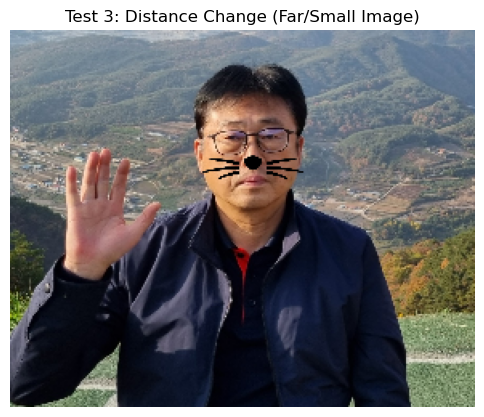

분석 결과: 얼굴 픽셀 수가 적어지면 랜드마크 포인트들이 조밀하게 뭉쳐 정밀도가 감소합니다.


In [5]:
# 이미지를 1/3 크기로 축소하여 멀리서 찍은 효과 시뮬레이션
h, w = img_rgb.shape[:2]
img_far = cv2.resize(img_rgb, (w // 3, h // 3))

img_far_show = img_far.copy()
rects_far = detector_hog(img_far, 1)

if len(rects_far) > 0:
    points = predictor(img_far, rects_far[0])
    x_nose = points.part(33).x
    y_nose = points.part(33).y
    
    w_sticker = rects_far[0].width()
    h_sticker = rects_far[0].width()
    x = x_nose - w_sticker // 2
    y = y_nose - h_sticker // 2
    
    img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
    img_sticker = cv2.resize(img_sticker, (w_sticker, h_sticker))
    
    sticker_area = img_far_show[y:y+h_sticker, x:x+w_sticker]
    alpha_sticker = img_sticker[:, :, 3] / 255.0
    alpha_bg = 1.0 - alpha_sticker
    
    for c in range(3):
        sticker_area[:, :, c] = (alpha_sticker * img_sticker[:, :, c] + alpha_bg * sticker_area[:, :, c])
        
    plt.figure(figsize=(6, 6))
    plt.imshow(img_far_show)
    plt.title("Test 3: Distance Change (Far/Small Image)")
    plt.axis('off')
    plt.show()
    print("분석 결과: 얼굴 픽셀 수가 적어지면 랜드마크 포인트들이 조밀하게 뭉쳐 정밀도가 감소합니다.")
else:
    print("분석 결과: 거리가 너무 멀어지면 저해상도로 인해 얼굴 패턴을 인식하지 못합니다.")


# 문제점 찾아보기 

# 얼굴 각도에 따른 문제 (회전/기울기):

  현상: dlib의 HOG 디텍터는 정면 얼굴은 매우 잘 찾지만, 고개를 좌우로 돌리거나(Yaw), 갸우뚱하게 기울이면(Roll) 
       랜드마크 위치 계산이 어긋납니다.

  이유: 현재 코드는 스티커를 회전시키지 않고 수평 정방향으로만 붙이기 때문에, 고개가 기울어져도 스티커는 똑바로 서 
       있어서 부자연스럽습니다.

  해결책: 눈 대각선 각도나 입 꼬리 각도를 계산하여 OpenCV의 아핀 변환(cv2.getRotationMatrix2D)으로 스티커 자체를 
         회전시켜 합성해야 합니다.


 #  촬영 거리(멀리서 촬영) 및 누워서 촬영:

    현상: 너무 멀리서 찍으면 얼굴 정밀도가 떨어져 디텍터가 얼굴 영역 자체를 놓칠 수 있습니다. 
          완전히 옆으로 누워서 찍으면 검출 확률이 급격히 낮아집니다.

    이유:  dlib의 기본 정면 디텍터는 수직으로 똑바로 서 있는 얼굴의 특징점(HOG 패턴)을 기반으로 학습되었기 때문입니다.

    해결책: 딥러닝 기반 이미지 검출기(예: BlazeFace, 정교한 CNN 기반 모델)를 사용하거나 이미지를 회전시켜 가며 
           검출하는 기법이 필요합니다.  


 #  정확도와 실행 속도의 중요성:

    분석: 스노우(SNOW)나 인스타그램 같은 실제 서비스에서는 사용자가 움직일 때 실시간(최소 30 FPS 이상)으로 스티커가 
          딜레이 없이 쫓아와야 하므로 실행 속도가 극도로 중요합니다. 다만 속도를 올리기 위해 알고리즘을 경량화하면 정밀도가 
          떨어져 스티커가 덜덜 떨리는 현상(Jittering)이 발생하므로 두 지표의 적절한 트레이드오프(Trade-off)가 중요합니다.
























